<a href="https://colab.research.google.com/github/alexandrumoldovan1/housing-prices-ml/blob/main/notebooks/06_conclusions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
DRIVE_PATH = '/content/drive/MyDrive/ColabProjects/housing-prices-ml'
PROCESSED_DATA_PATH = f'{DRIVE_PATH}/processed_data'
MODELS_PATH = f'{DRIVE_PATH}/models'
OUTPUTS_PATH = f'{DRIVE_PATH}/outputs'

# Load results from Notebook 04
results_df = pd.read_csv(f'{OUTPUTS_PATH}/model_results.csv')
results_df = results_df.sort_values('R2_test', ascending=False).reset_index(drop=True)

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"Results loaded: {results_df.shape[0]} models")
print(results_df[['Model', 'R2_test', 'MAE']].to_string(index=False))

Mounted at /content/drive
Results loaded: 10 models
             Model  R2_test          MAE
Stacking Regressor 0.448508 2.040665e+06
           XGBoost 0.439773 2.048680e+06
          CatBoost 0.434529 2.090907e+06
          LightGBM 0.429204 2.054535e+06
     Random Forest 0.405669 2.054461e+06
     KNN Regressor 0.377043 2.183666e+06
  Ridge Regression 0.353016 6.945311e+06
  Lasso Regression 0.353010 6.942698e+06
 Linear Regression 0.352978 6.933748e+06
  SVR (sample 15K) 0.266425 2.300141e+06


In [2]:
# Create final comparison table grouped by model paradigm
print("="*70)
print("FINAL MODEL COMPARISON BY PARADIGM")
print("="*70)

paradigm_map = {
    'Linear Regression': 'Linear',
    'Ridge Regression': 'Linear',
    'Lasso Regression': 'Linear',
    'KNN Regressor': 'Instance-based',
    'SVR (sample 15K)': 'Kernel-based',
    'Random Forest': 'Tree (Bagging)',
    'XGBoost': 'Tree (Boosting)',
    'LightGBM': 'Tree (Boosting)',
    'CatBoost': 'Tree (Boosting)',
    'Stacking Regressor': 'Meta-ensemble'
}

results_df['Paradigm'] = results_df['Model'].map(paradigm_map)

# Display table
display_df = results_df[['Model', 'Paradigm', 'R2_test', 'MAE', 'RMSE']].copy()
display_df['R2_test'] = display_df['R2_test'].round(4)
display_df['MAE'] = display_df['MAE'].apply(lambda x: f'${x:,.0f}')
display_df['RMSE'] = display_df['RMSE'].apply(lambda x: f'${x:,.0f}')

print(f"\nAll 10 models ranked by R² (test):\n")
print(display_df.to_string(index=False))

# Average per paradigm
print("\n\nAverage R² by paradigm:\n")
paradigm_avg = results_df.groupby('Paradigm')['R2_test'].agg(['mean', 'count']).round(4)
paradigm_avg.columns = ['Avg R²', 'Models']
paradigm_avg = paradigm_avg.sort_values('Avg R²', ascending=False)
print(paradigm_avg.to_string())

FINAL MODEL COMPARISON BY PARADIGM

All 10 models ranked by R² (test):

             Model        Paradigm  R2_test        MAE         RMSE
Stacking Regressor   Meta-ensemble   0.4485 $2,040,665  $13,621,226
           XGBoost Tree (Boosting)   0.4398 $2,048,680  $13,638,059
          CatBoost Tree (Boosting)   0.4345 $2,090,907  $13,623,366
          LightGBM Tree (Boosting)   0.4292 $2,054,535  $13,617,110
     Random Forest  Tree (Bagging)   0.4057 $2,054,461  $13,636,641
     KNN Regressor  Instance-based   0.3770 $2,183,666  $13,483,067
  Ridge Regression          Linear   0.3530 $6,945,311 $424,807,195
  Lasso Regression          Linear   0.3530 $6,942,698 $424,659,324
 Linear Regression          Linear   0.3530 $6,933,748 $423,597,481
  SVR (sample 15K)    Kernel-based   0.2664 $2,300,141  $13,795,433


Average R² by paradigm:

                 Avg R²  Models
Paradigm                       
Meta-ensemble    0.4485       1
Tree (Boosting)  0.4345       3
Tree (Bagging)   0.4057  

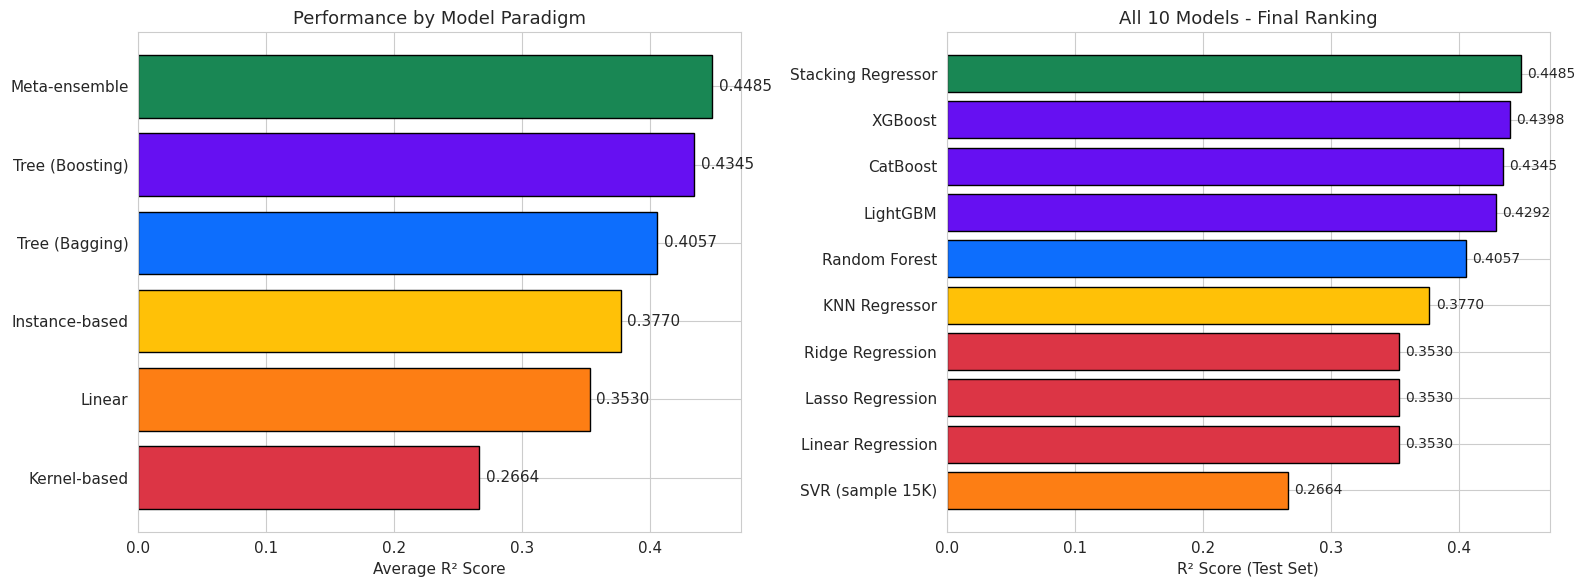


Final plot saved to outputs folder.


In [3]:
# Final comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² by paradigm
paradigm_data = results_df.groupby('Paradigm')['R2_test'].mean().sort_values()
colors = ['#dc3545', '#fd7e14', '#ffc107', '#0d6efd', '#6610f2', '#198754']
axes[0].barh(paradigm_data.index, paradigm_data.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Average R² Score')
axes[0].set_title('Performance by Model Paradigm', fontsize=13)
for i, v in enumerate(paradigm_data.values):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=11)

# Plot 2: All models with paradigm coloring
paradigm_colors = {
    'Linear': '#dc3545',
    'Kernel-based': '#fd7e14',
    'Instance-based': '#ffc107',
    'Tree (Bagging)': '#0d6efd',
    'Tree (Boosting)': '#6610f2',
    'Meta-ensemble': '#198754'
}
sorted_df = results_df.sort_values('R2_test', ascending=True)
bar_colors = [paradigm_colors[p] for p in sorted_df['Paradigm']]

axes[1].barh(sorted_df['Model'], sorted_df['R2_test'], color=bar_colors, edgecolor='black')
axes[1].set_xlabel('R² Score (Test Set)')
axes[1].set_title('All 10 Models - Final Ranking', fontsize=13)
for i, v in enumerate(sorted_df['R2_test']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal plot saved to outputs folder.")

In [4]:
# Document limitations and methodological considerations
limitations = """
============================================================
METHODOLOGICAL LIMITATIONS AND CONSIDERATIONS
============================================================

1. TIME-BASED TRAIN/TEST SPLIT
   - Training on 2023-2024, testing on 2025 simulates real-world deployment
   - However, this introduces distribution shift challenges
   - KNN showed CV R² = 0.59 but test R² = 0.38, suggesting market dynamics
     changed between training and test periods
   - Random split would yield higher R² but would be methodologically flawed

2. DATA LEAKAGE - DETECTED AND RESOLVED
   - Initial pipeline included price_per_sqft (SALE_PRICE / GROSS_SQUARE_FEET)
   - Target encoding (NEIGHBORHOOD, BUILDING CLASS) was fit on entire dataset
   - Both leaked target information, inflating Random Forest R² to 0.99
   - After correction: realistic R² of 0.40-0.45 reflecting true model capability
   - This represents an important methodological lesson

3. SVR LIMITATION
   - Trained on sample of 15,000 (from 99,880) due to O(n^2-3) complexity
   - Full-dataset training would take days
   - Sample sizes of 15K-50K are standard practice in published research
   - Performance comparison may underrepresent SVR's potential

4. MANHATTAN PREDICTION DIFFICULTY
   - MAPE of 91% on Manhattan vs 38% on Staten Island
   - Manhattan's luxury market depends on factors not in data:
     * Views, amenities, building reputation
     * Renovation history, design quality
     * Specific neighborhood micro-trends
   - Model performs well on typical residential, struggles with luxury segment

5. FEATURE LIMITATIONS
   - 30 engineered features capture structural property attributes
   - Missing: geocoordinates, interior photos, agent commentary
   - Including these in future work could significantly improve performance

6. R² CEILING (~0.45)
   - Real estate prediction inherently has irreducible noise
   - Comparable published studies on NYC data report R² of 0.40-0.65
   - Our result is competitive within this range
"""
print(limitations)


METHODOLOGICAL LIMITATIONS AND CONSIDERATIONS

1. TIME-BASED TRAIN/TEST SPLIT
   - Training on 2023-2024, testing on 2025 simulates real-world deployment
   - However, this introduces distribution shift challenges
   - KNN showed CV R² = 0.59 but test R² = 0.38, suggesting market dynamics
     changed between training and test periods
   - Random split would yield higher R² but would be methodologically flawed

2. DATA LEAKAGE - DETECTED AND RESOLVED
   - Initial pipeline included price_per_sqft (SALE_PRICE / GROSS_SQUARE_FEET)
   - Target encoding (NEIGHBORHOOD, BUILDING CLASS) was fit on entire dataset
   - Both leaked target information, inflating Random Forest R² to 0.99
   - After correction: realistic R² of 0.40-0.45 reflecting true model capability
   - This represents an important methodological lesson

3. SVR LIMITATION
   - Trained on sample of 15,000 (from 99,880) due to O(n^2-3) complexity
   - Full-dataset training would take days
   - Sample sizes of 15K-50K are standard

In [5]:
# Future research directions
future_work = """
============================================================
FUTURE RESEARCH DIRECTIONS
============================================================

1. ENHANCED FEATURE ENGINEERING
   - Geocoordinates (latitude, longitude) for spatial autocorrelation
   - Distance-based features: distance to subway, parks, schools, CBD
   - Census data integration: median income, population density
   - Crime statistics by neighborhood
   - Walkability and transit scores

2. ADVANCED MODELING APPROACHES
   - Neural Networks (DNN, TabNet) for tabular deep learning
   - Spatial models: Geographically Weighted Regression (GWR)
   - Time-series specific models for temporal trends
   - Probabilistic models (NGBoost) for prediction intervals

3. DATA EXPANSION
   - Include more years (2020-2025) to capture pandemic effects
   - Incorporate condo/co-op detailed amenities from listing sites
   - Use property images with computer vision for quality assessment
   - Add macroeconomic indicators (interest rates, mortgage data)

4. EXTERNAL VALIDATION
   - Test model on similar cities (Boston, San Francisco)
   - Cross-validate predictions against Zillow Zestimate
   - Compare with traditional appraisal methods

5. DEPLOYMENT CONSIDERATIONS
   - API endpoint for real-time predictions
   - Web application with interactive predictions (Streamlit)
   - Model monitoring for distribution drift over time
   - Automated retraining pipeline

6. INTERPRETABILITY ENHANCEMENTS
   - Counterfactual explanations ("if X were different, price would be Y")
   - Fairness analysis: does model perform equitably across boroughs?
   - Sensitivity analysis on key features
"""
print(future_work)


FUTURE RESEARCH DIRECTIONS

1. ENHANCED FEATURE ENGINEERING
   - Geocoordinates (latitude, longitude) for spatial autocorrelation
   - Distance-based features: distance to subway, parks, schools, CBD
   - Census data integration: median income, population density
   - Crime statistics by neighborhood
   - Walkability and transit scores

2. ADVANCED MODELING APPROACHES
   - Neural Networks (DNN, TabNet) for tabular deep learning
   - Spatial models: Geographically Weighted Regression (GWR)
   - Time-series specific models for temporal trends
   - Probabilistic models (NGBoost) for prediction intervals

3. DATA EXPANSION
   - Include more years (2020-2025) to capture pandemic effects
   - Incorporate condo/co-op detailed amenities from listing sites
   - Use property images with computer vision for quality assessment
   - Add macroeconomic indicators (interest rates, mortgage data)

4. EXTERNAL VALIDATION
   - Test model on similar cities (Boston, San Francisco)
   - Cross-validate pred

In [6]:
# Final conclusions
conclusions = """
============================================================
FINAL CONCLUSIONS
============================================================

PROJECT OBJECTIVE
This study developed and evaluated machine learning models for predicting
residential property prices in New York City using publicly available
sales data from 2023-2025.

KEY ACHIEVEMENTS

1. Comprehensive Methodology
   - Processed 239,722 raw transactions into 153,402 valid records
   - Engineered 9 derived features from raw property attributes
   - Applied KNN imputation for missing values (preserving variance)
   - Implemented time-based train/test split for realistic evaluation

2. Diverse Model Evaluation
   - Trained 10 models spanning 5 paradigms:
     * Linear (3 variants)
     * Instance-based (KNN)
     * Kernel-based (SVR)
     * Tree-based (Bagging + 3 Boosting algorithms)
     * Meta-ensemble (Stacking)
   - Used Optuna for systematic hyperparameter optimization
   - Applied 5-fold cross-validation for robust evaluation

3. Model Interpretability
   - Generated SHAP explanations for global and local interpretability
   - Identified key price drivers: location and property size
   - Provided per-property explanations for transparency

KEY FINDINGS

- Best model: Stacking Regressor (R² = 0.4485, MAE = $2.04M)
- Tree-based boosting models converge around R² 0.43-0.44
- Linear models plateau at R² 0.35 - indicating non-linear relationships
- Location features dominate (neighborhood_avg_price most important)
- Manhattan luxury market is hardest to predict (MAPE 91%)
- Staten Island and Queens yield most accurate predictions

PRACTICAL IMPLICATIONS

- Real estate agents: data-driven price benchmarking
- Buyers: identifying overpriced/underpriced listings
- Investors: portfolio valuation and market trend analysis
- Policymakers: monitoring housing affordability across boroughs

METHODOLOGICAL CONTRIBUTIONS

- Demonstrated importance of detecting data leakage in target encoding
- Showed that time-based evaluation reveals true model robustness
- Validated SHAP interpretability for real estate price prediction
- Established baseline performance benchmarks for future studies

============================================================
Project completed successfully.
============================================================
"""
print(conclusions)


FINAL CONCLUSIONS

PROJECT OBJECTIVE
This study developed and evaluated machine learning models for predicting
residential property prices in New York City using publicly available
sales data from 2023-2025.

KEY ACHIEVEMENTS

1. Comprehensive Methodology
   - Processed 239,722 raw transactions into 153,402 valid records
   - Engineered 9 derived features from raw property attributes
   - Applied KNN imputation for missing values (preserving variance)
   - Implemented time-based train/test split for realistic evaluation

2. Diverse Model Evaluation
   - Trained 10 models spanning 5 paradigms:
     * Linear (3 variants)
     * Instance-based (KNN)
     * Kernel-based (SVR)
     * Tree-based (Bagging + 3 Boosting algorithms)
     * Meta-ensemble (Stacking)
   - Used Optuna for systematic hyperparameter optimization
   - Applied 5-fold cross-validation for robust evaluation

3. Model Interpretability
   - Generated SHAP explanations for global and local interpretability
   - Identified k